In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Datos
anos = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
IPC = np.array([10860, 11750, 12840, 13330, 14030, 13780, 14590, 15050, 15910, 16110])
PIB = np.array([7.70268E+11, 8.66346E+11, 9.66736E+11, 1.04339E+12, 1.09907E+12, 8.95313E+11, 1.05163E+12, 1.17009E+12, 1.18646E+12, 1.26091E+12])
EV = np.array([75.24, 75.49, 75.74, 75.9, 76.25, 76.46, 76.69, 76.91, 77.14, 77])

# Función para realizar regresión lineal
def realizar_regresion(X, Y, nombre_X, nombre_Y):
    X = sm.add_constant(X)  # Agregar intercepto
    model = sm.OLS(Y, X).fit()
    print(f"\nResumen de la regresión entre {nombre_X} y {nombre_Y}:")
    print(model.summary())

    # Validación con scikit-learn
    reg = LinearRegression()
    reg.fit(X[:, 1:], Y)  # Quitamos la columna de unos
    Y_pred = reg.predict(X[:, 1:])

    print("\nResultados con scikit-learn:")
    print(f"Coeficientes: {reg.coef_}")
    print(f"Intercepto: {reg.intercept_}")
    print(f"R^2: {r2_score(Y, Y_pred)}")
    print(f"Error cuadrático medio: {mean_squared_error(Y, Y_pred)}")

# Regresión para IPC y EV
realizar_regresion(EV.reshape(-1, 1), IPC, "EV", "IPC")

# Regresión para PIB y EV
realizar_regresion(EV.reshape(-1, 1), PIB, "EV", "PIB")



Resumen de la regresión entre EV y IPC:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     160.4
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           1.42e-06
Time:                        00:26:43   Log-Likelihood:                -72.812
No. Observations:                  10   AIC:                             149.6
Df Residuals:                       8   BIC:                             150.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit

# Datos
anos = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
IPC = np.array([10860, 11750, 12840, 13330, 14030, 13780, 14590, 15050, 15910, 16110])
PIB = np.array([7.70268E+11, 8.66346E+11, 9.66736E+11, 1.04339E+12, 1.09907E+12, 8.95313E+11, 1.05163E+12, 1.17009E+12, 1.18646E+12, 1.26091E+12])
EV = np.array([75.24, 75.49, 75.74, 75.9, 76.25, 76.46, 76.69, 76.91, 77.14, 77])

# Funciones de ajuste
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exponential(x, a, b):
    return a * np.exp(b * x)

def logarithmic(x, a, b):
    return a + b * np.log(x)

# Función para realizar regresiones
def realizar_regresion(X, Y, nombre_X, nombre_Y):
    X_lin = sm.add_constant(X)
    model_lin = sm.OLS(Y, X_lin).fit()
    print(f"\nRegresión Lineal entre {nombre_X} y {nombre_Y}:")
    print(model_lin.summary())

    # Regresión cuadrática
    popt_quad, _ = curve_fit(quadratic, X.flatten(), Y)
    Y_quad_pred = quadratic(X, *popt_quad)
    r2_quad = r2_score(Y, Y_quad_pred)
    print(f"\nRegresión Cuadrática R^2: {r2_quad}")

    # Regresión cúbica
    popt_cubic, _ = curve_fit(cubic, X.flatten(), Y)
    Y_cubic_pred = cubic(X, *popt_cubic)
    r2_cubic = r2_score(Y, Y_cubic_pred)
    print(f"\nRegresión Cúbica R^2: {r2_cubic}")

    # Regresión exponencial
    popt_exp, _ = curve_fit(exponential, X.flatten(), Y, maxfev=10000)
    Y_exp_pred = exponential(X, *popt_exp)
    r2_exp = r2_score(Y, Y_exp_pred)
    print(f"\nRegresión Exponencial R^2: {r2_exp}")

    # Regresión logarítmica
    popt_log, _ = curve_fit(logarithmic, X.flatten(), Y)
    Y_log_pred = logarithmic(X, *popt_log)
    r2_log = r2_score(Y, Y_log_pred)
    print(f"\nRegresión Logarítmica R^2: {r2_log}")

# Regresiones para IPC y EV
realizar_regresion(EV.reshape(-1, 1), IPC, "EV", "IPC")

# Regresiones para PIB y EV
realizar_regresion(EV.reshape(-1, 1), PIB, "EV", "PIB")



Regresión Lineal entre EV y IPC:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     160.4
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           1.42e-06
Time:                        00:31:21   Log-Likelihood:                -72.812
No. Observations:                  10   AIC:                             149.6
Df Residuals:                       8   BIC:                             150.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.761e

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
<ipython-input-2-ecc4aaf44eac>:35: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_quad, _ = curve_fit(quadratic, X.flatten(), Y)
<ipython-input-2-ecc4aaf44eac>:41: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_cubic, _ = curve_fit(cubic, X.flatten(), Y)
<ipython-input-2-ecc4aaf44eac>:53: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_log, _ = curve_fit(logarithmic, X.flatten(), Y)


Saving SERIEuno.csv to SERIEuno (4).csv
       X  YEAR_  MONTH_     DATE_
0   80.5   1968       1  JAN 1968
1   84.6   1968       2  FEB 1968
2  126.6   1968       3  MAR 1968
3  162.0   1968       4  APR 1968
4  140.9   1968       5  MAY 1968
ADF Statistic: -2.657832923081698
p-value: 0.08162352371719261
Critical Values: {'1%': np.float64(-3.474120870218417), '5%': np.float64(-2.880749791423677), '10%': np.float64(-2.5770126333102494)}
La serie no es estacionaria.
Lambda de Box-Cox: 0.6929380456127165


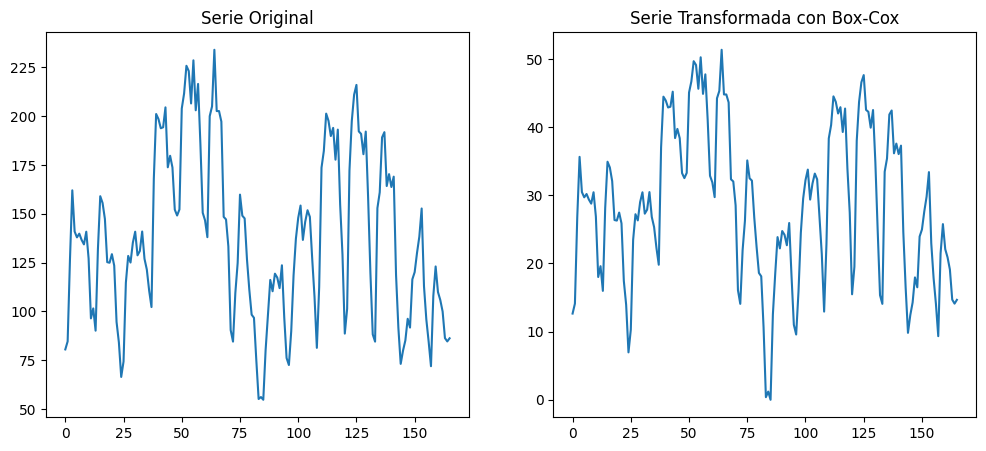

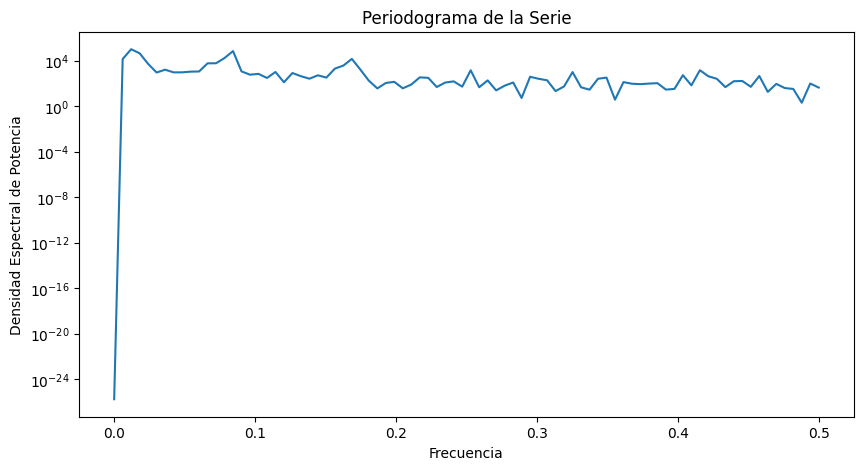

                               SARIMAX Results                                
Dep. Variable:                      X   No. Observations:                  166
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -741.152
Date:                Wed, 02 Apr 2025   AIC                           1488.305
Time:                        01:40:10   BIC                           1497.623
Sample:                             0   HQIC                          1492.087
                                - 166                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1971      0.368      0.535      0.592      -0.524       0.919
ma.L1          0.0387      0.354      0.109      0.913      -0.655       0.732
sigma2       466.6078     43.337     10.767      0.0

In [ ]:
# Instalar paquetes necesarios en Colab
!pip install statsmodels scipy pandas matplotlib numpy openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from scipy.signal import periodogram

# Cargar datos desde archivo en Google Colab
from google.colab import files
uploaded = files.upload()

# Detectar el nombre del archivo subido
archivo = list(uploaded.keys())[0]  # Obtiene el nombre del archivo subido automáticamente

# Leer el archivo, sea .xlsx o .csv
if archivo.endswith('.xlsx'):
    df = pd.read_excel(archivo, engine='openpyxl')
elif archivo.endswith('.csv'):
    df = pd.read_csv(archivo)
else:
    raise ValueError("Formato de archivo no soportado. Sube un archivo .xlsx o .csv.")

# Convertir la columna de fecha en índice si es necesario
if 'Fecha' in df.columns:
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    df.set_index('Fecha', inplace=True)

# Verificar los primeros datos
print(df.head())

# Prueba de Raíz Unitaria (Dickey-Fuller Aumentada)
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])
    if result[1] <= 0.05:
        print("La serie es estacionaria.")
    else:
        print("La serie no es estacionaria.")

# Aplicar prueba de ADF
columna = df.columns[0]  # Usar la primera columna de datos automáticamente
adf_test(df[columna])

# Transformación Box-Cox (si la serie no es estacionaria)
df[columna + '_boxcox'], lambda_bc = boxcox(df[columna] - df[columna].min() + 1)  # Ajuste para valores positivos
print(f"Lambda de Box-Cox: {lambda_bc}")

# Graficar la serie original y transformada
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(df[columna])
plt.title("Serie Original")

plt.subplot(1,2,2)
plt.plot(df[columna + '_boxcox'])
plt.title("Serie Transformada con Box-Cox")
plt.show()

# Graficar Periodograma
frecuencias, espectro = periodogram(df[columna])
plt.figure(figsize=(10,5))
plt.semilogy(frecuencias, espectro)
plt.title("Periodograma de la Serie")
plt.xlabel("Frecuencia")
plt.ylabel("Densidad Espectral de Potencia")
plt.show()

# Modelo ARIMA
modelo = ARIMA(df[columna], order=(1,1,1))  # Parámetros iniciales
resultado = modelo.fit()
print(resultado.summary())
